In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import predict_zeroth_order
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.surrogates import generate_aaft_surrogates, generate_iaaft_surrogates


lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

Spectral Error (L2 Norm): 9.29e-04


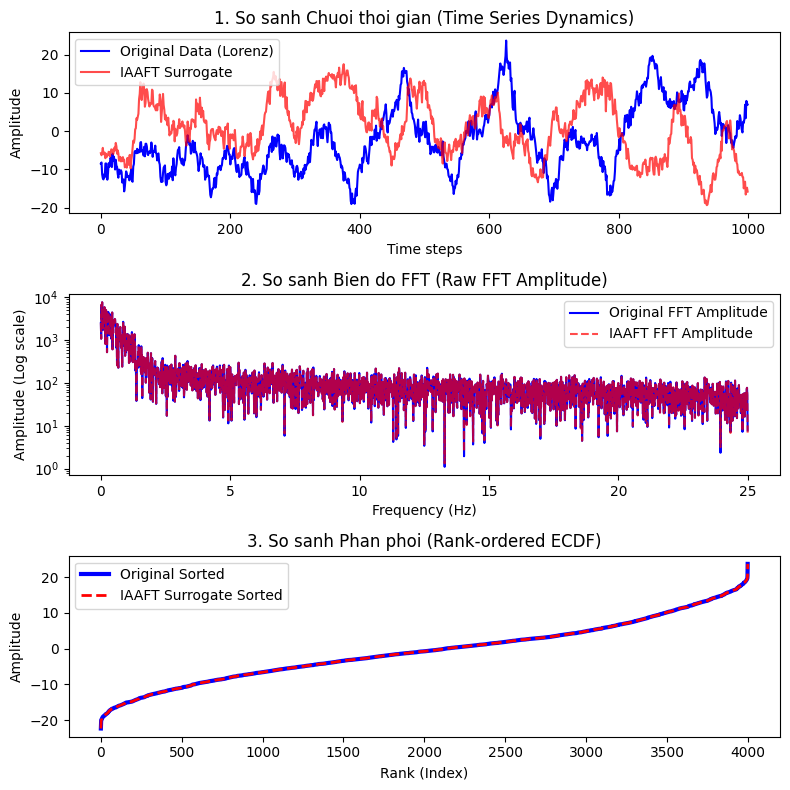

In [3]:
surrogates = generate_iaaft_surrogates(
    x_clored_noise, 
    M=1, 
    max_iter=100, 
    random_seed=42
)
surr_x = surrogates[0]

# --- Tính toán sai số định lượng ---
orig_fft = np.abs(np.fft.rfft(x_clored_noise))
surr_fft = np.abs(np.fft.rfft(surr_x))

spec_err = np.linalg.norm(orig_fft - surr_fft) / np.linalg.norm(orig_fft)
print(f"Spectral Error (L2 Norm): {spec_err:.2e}")

# --- Vẽ đồ thị so sánh ---
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# 1. So sanh Chuoi thoi gian
axes[0].plot(x_clored_noise[:1000], label='Original Data (Lorenz)', color='blue')
axes[0].plot(surr_x[:1000], label='IAAFT Surrogate', color='red', alpha=0.7)
axes[0].set_title("1. So sanh Chuoi thoi gian (Time Series Dynamics)")
axes[0].set_xlabel("Time steps")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# 2. So sanh Pho nang luong (Raw FFT Amplitude)
fs = 50  
freq = np.fft.rfftfreq(len(x_clored_noise), d=1/fs)

axes[1].semilogy(freq, orig_fft, label='Original FFT Amplitude', color='blue')
axes[1].semilogy(freq, surr_fft, label='IAAFT FFT Amplitude', color='red', alpha=0.7, linestyle='--')
axes[1].set_title("2. So sanh Bien do FFT (Raw FFT Amplitude)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (Log scale)")
axes[1].legend()

# 3. So sanh Phan phoi bien do (ECDF / Sorted Values)
orig_sorted = np.sort(x_clored_noise)
surr_sorted = np.sort(surr_x)

axes[2].plot(orig_sorted, label='Original Sorted', color='blue', linewidth=3)
axes[2].plot(surr_sorted, label='IAAFT Surrogate Sorted', color='red', linestyle='--', linewidth=2)
axes[2].set_title("3. So sanh Phan phoi (Rank-ordered ECDF)")
axes[2].set_xlabel("Rank (Index)")
axes[2].set_ylabel("Amplitude")
axes[2].legend()

plt.tight_layout()
plt.show()